# M3: EV Fleet Projection 2027
## IE Sustainability Datathon March 2026, Iberdrola Challenge

**Objective:** Project the total EV fleet in Spain for 2027 (`total_ev_projected_2027`), a mandatory input for File 1.csv.

**Methodology:** Uses the SARIMA forecasting approach from the mandatory datos.gob.es fork:  
→ **Fork URL:** https://github.com/Jvilpi/Laboratorio-de-Datos  
→ **Original notebook:** `Data Science/Ruta a la electrificación de la Movilidad/Codigo/Notebook.ipynb`

**This notebook:**
1. Replicates the SARIMA methodology from the fork (same model specification)
2. Extends the forecast from 12 months (2024) to 48 months (2024–2027)
3. Computes `total_ev_projected_2027` = cumulative historical fleet + projected registrations 2024–2027

**Scope:** Pure battery-electric vehicles (DGT propulsion code `'6'` / label `'Electrico'`), consistent with the fork's BEV definition.

---
**Data source:** DGT vehicle registrations via datos.gob.es fork (2015–2023 pre-processed parquets)

## 0. Setup: Install Dependencies

In [1]:
#!pip install statsmodels pandas numpy matplotlib pyarrow -q

In [2]:
import os
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm

# Suppress statsmodels convergence noise; keep all other warnings active
warnings.filterwarnings('ignore', category=UserWarning, module='statsmodels')
warnings.filterwarnings('ignore', category=FutureWarning, module='statsmodels')

# ── Fork reference (mandatory) ─────────────────────────────────────────────────
FORK_URL = "https://github.com/Jvilpi/Laboratorio-de-Datos"
FORK_RAW_BASE = (
    "https://raw.githubusercontent.com/Jvilpi/Laboratorio-de-Datos/main/"
    "Data%20Science/Ruta%20a%20la%20electrificaci%C3%B3n%20de%20la%20Movilidad/Datos/"
)

# DGT propulsion code '6' maps to 'Electrico' (pure BEV)
EV_LABEL = 'Electrico'

print(f"Fork reference: {FORK_URL}")
print("Dependencies loaded successfully.")

Fork reference: https://github.com/Jvilpi/Laboratorio-de-Datos
Dependencies loaded successfully.


## 1. Download Historical Data from Fork (2015–2023)

Pre-processed parquet files (DGT registrations) are stored directly in the fork. This cell downloads any missing files using the same path structure as the original notebook.

In [3]:
PARQUET_DIR = "../Data/raw/ev_fleet_projections_datosgob/parquet"
os.makedirs(PARQUET_DIR, exist_ok=True)

ano_inicio, ano_fin = 2015, 2023

archivos_parquet = [
    (FORK_RAW_BASE + f"{ano}_{str(mes).zfill(2)}.parquet",
     f"{ano}_{str(mes).zfill(2)}.parquet")
    for ano in range(ano_inicio, ano_fin + 1)
    for mes in range(1, 13)
]

print(f"Files expected: {len(archivos_parquet)}")

downloaded, skipped, failed = 0, 0, []
for url, fname in archivos_parquet:
    fpath = os.path.join(PARQUET_DIR, fname)
    if os.path.exists(fpath):
        skipped += 1
        continue
    r = requests.get(url, timeout=30)
    if r.status_code == 200:
        with open(fpath, 'wb') as f:
            f.write(r.content)
        downloaded += 1
    else:
        failed.append(fname)
        print(f"  WARNING: {fname} returned HTTP {r.status_code}")

if failed:
    raise RuntimeError(f"Failed to download {len(failed)} file(s): {failed}")

print(f"Downloaded: {downloaded} | Already present: {skipped}")
n_parquet = len([f for f in os.listdir(PARQUET_DIR) if f.endswith('.parquet')])
print(f"Parquet files in dir: {n_parquet} (expected 108)")

Files expected: 108
Downloaded: 108 | Already present: 0
Parquet files in dir: 108 (expected 108)


## 2. Load & Filter Data

Filtering logic follows the fork exactly:
- Vehicle type: `COD_TIPO == '40'` (passenger cars; stored as string in parquet)
- Registration type: `CLAVE_TRAMITE` in `['1', '5', 'B']` (firm registrations)
- Propulsion mapping: DGT numeric code `'6'` → `'Electrico'` (pure BEV)
- EV filter: `COD_PROPULSION_ITV == 'Electrico'` (after numeric-to-label mapping)

In [4]:
dfs = []
for fname in sorted(os.listdir(PARQUET_DIR)):
    if fname.endswith('.parquet'):
        dfs.append(pd.read_parquet(os.path.join(PARQUET_DIR, fname)))

df_raw = pd.concat(dfs, ignore_index=True)
print(f"Total raw records loaded: {len(df_raw):,}")
print(f"Columns: {df_raw.columns.tolist()}")

Total raw records loaded: 14,588,498
Columns: ['FEC_MATRICULA', 'MARCA_ITV', 'MODELO_ITV', 'COD_TIPO', 'COD_PROPULSION_ITV', 'CLAVE_TRAMITE', 'CATEGORÍA_VEHÍCULO_ELÉCTRICO']


In [5]:
# DGT numeric propulsion codes → human-readable labels
cod_propulsion = {
    '0': 'Diesel',
    '1': 'Gasolina',
    '2': 'Hibrido Gasolina',
    '3': 'GNC',
    '4': 'GNL',
    '5': 'GLP',
    '6': 'Electrico',              # BEV, target category
    '7': 'Hidrogeno',
    '8': 'Gasolina-GNC',
    '9': 'Gasolina-GLP',
    'A': 'Hibrido Gasolina-Electrico',
    'B': 'Hibrido Diesel-Electrico',
    'C': 'Otro',
    'D': 'Diesel-GNC',
    'E': 'Diesel-GLP',
}

df = df_raw.copy()

df['COD_PROPULSION_ITV'] = df['COD_PROPULSION_ITV'].astype(str).str.strip()
df['COD_PROPULSION_ITV'] = df['COD_PROPULSION_ITV'].replace(cod_propulsion)

# Passenger cars only; COD_TIPO is stored as a string in these parquets
df['COD_TIPO'] = df['COD_TIPO'].astype(str).str.strip()
df = df[df['COD_TIPO'] == '40']
print(f"After COD_TIPO filter:      {len(df):>9,} records")

# Firm registrations only (excludes transfers and other non-sale events)
df['CLAVE_TRAMITE'] = df['CLAVE_TRAMITE'].astype(str).str.strip()
df = df[df['CLAVE_TRAMITE'].isin(['1', '5', 'B'])]
print(f"After CLAVE_TRAMITE filter: {len(df):>9,} records")

# Extract year and month from FEC_MATRICULA (format: DDMMYYYY)
df['ANO'] = df['FEC_MATRICULA'].astype(str).str[4:8].astype(int)
df['MES'] = df['FEC_MATRICULA'].astype(str).str[2:4].astype(int)

# Drop any records with an unrecognised propulsion type
df = df[df['COD_PROPULSION_ITV'].isin(cod_propulsion.values())]
print(f"After propulsion filter:    {len(df):>9,} records")
print(f"Year range: {df['ANO'].min()} – {df['ANO'].max()}")

print()
print('Propulsion breakdown (2023):')
print(df[df['ANO'] == 2023]['COD_PROPULSION_ITV'].value_counts())
print()
print(f"EV records total ('{EV_LABEL}'): "
      f"{(df['COD_PROPULSION_ITV'] == EV_LABEL).sum():,}")

After COD_TIPO filter:      10,379,959 records
After CLAVE_TRAMITE filter: 10,337,687 records
After propulsion filter:    10,332,822 records
Year range: 1923 – 2023

Propulsion breakdown (2023):
COD_PROPULSION_ITV
Diesel                        743834
Gasolina                      213284
Hibrido Gasolina               57381
Electrico                      27928
Hidrogeno                        295
Otro                              19
Gasolina-GNC                      14
Gasolina-GLP                      13
Hibrido Gasolina-Electrico         7
GNC                                6
Hibrido Diesel-Electrico           3
Name: count, dtype: int64

EV records total ('Electrico'): 113,624


## 3. Build Monthly EV Time Series

Groups registrations by year and month to produce a monthly BEV count series, following the fork's approach.

Monthly EV time series: 108 observations (expected 108)
Range: Jan 2015 → Dec 2023

Annual totals:
FECHA
2015     2434
2016     1356
2017     3940
2018    18016
2019    21235
2020    10161
2021    13656
2022    14898
2023    27928
Name: MATRICULACIONES, dtype: int64


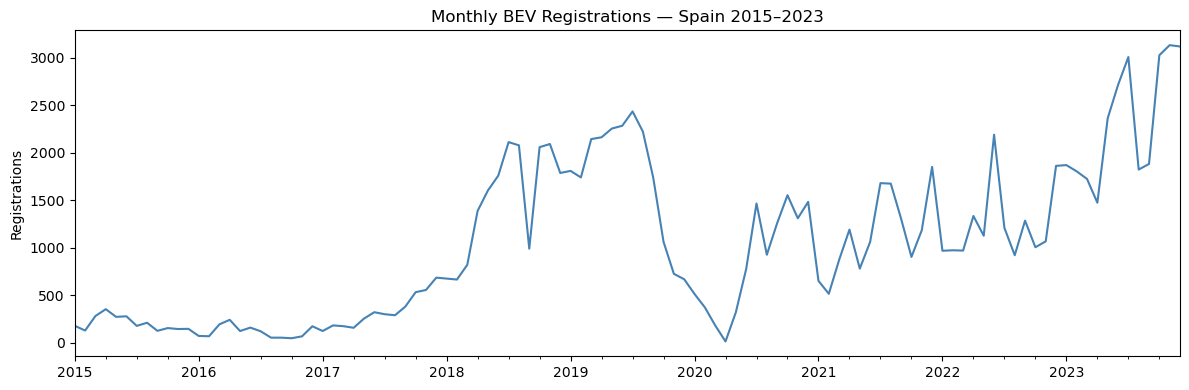

In [6]:
# Monthly BEV registration counts, following the fork's df_7 construction
df_ev = df[df['COD_PROPULSION_ITV'] == EV_LABEL].copy()

df_7 = df_ev.groupby(['ANO', 'MES']).size().reset_index(name='MATRICULACIONES')
df_7['FECHA'] = pd.to_datetime(df_7['ANO'].astype(str) + '-' + df_7['MES'].astype(str))
df_7 = df_7.set_index('FECHA').sort_index()
df_7 = df_7[['MATRICULACIONES']]
df_7 = df_7.asfreq('MS')  # monthly-start frequency required by SARIMAX

print(f"Monthly EV time series: {len(df_7)} observations (expected 108)")
print(f"Range: {df_7.index.min().strftime('%b %Y')} → {df_7.index.max().strftime('%b %Y')}")
print(f"\nAnnual totals:")
print(df_7.resample('YE')['MATRICULACIONES'].sum().rename(lambda d: d.year))

fig, ax = plt.subplots(figsize=(12, 4))
df_7['MATRICULACIONES'].plot(ax=ax,
                             title='Monthly BEV Registrations, Spain 2015–2023',
                             color='steelblue', linewidth=1.5)
ax.set_ylabel('Registrations')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 4. SARIMA Model

Model specification matches the fork exactly:  
`SARIMAX(log(MATRICULACIONES), order=(1,0,2), seasonal_order=(1,0,1,12))`

**Why log-transform?** The EV registration series grows exponentially, so log-transforming it stabilises variance and improves SARIMA fit (consistent with the fork's approach).

In [7]:
# Same SARIMA specification as the fork
modelo = sm.tsa.statespace.SARIMAX(
    np.log(df_7['MATRICULACIONES']),
    order=(1, 0, 2),
    seasonal_order=(1, 0, 1, 12)
)
modelo_entrenado = modelo.fit(disp=False)

print(modelo_entrenado.summary())

                                      SARIMAX Results                                       
Dep. Variable:                      MATRICULACIONES   No. Observations:                  108
Model:             SARIMAX(1, 0, 2)x(1, 0, [1], 12)   Log Likelihood                 -89.578
Date:                              Sat, 11 Apr 2026   AIC                            191.156
Time:                                      15:01:47   BIC                            207.249
Sample:                                  01-01-2015   HQIC                           197.681
                                       - 12-01-2023                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9971      0.018     55.041      0.000       0.962       1.033
ma.L1         -0.20

## 5. Extended Forecast: 2024–2027

The original notebook forecasts 12 months (2024). Here we extend to **48 months** to cover the full 2024–2027 horizon required by the datathon.

The model specification is unchanged; only the forecast horizon is extended.

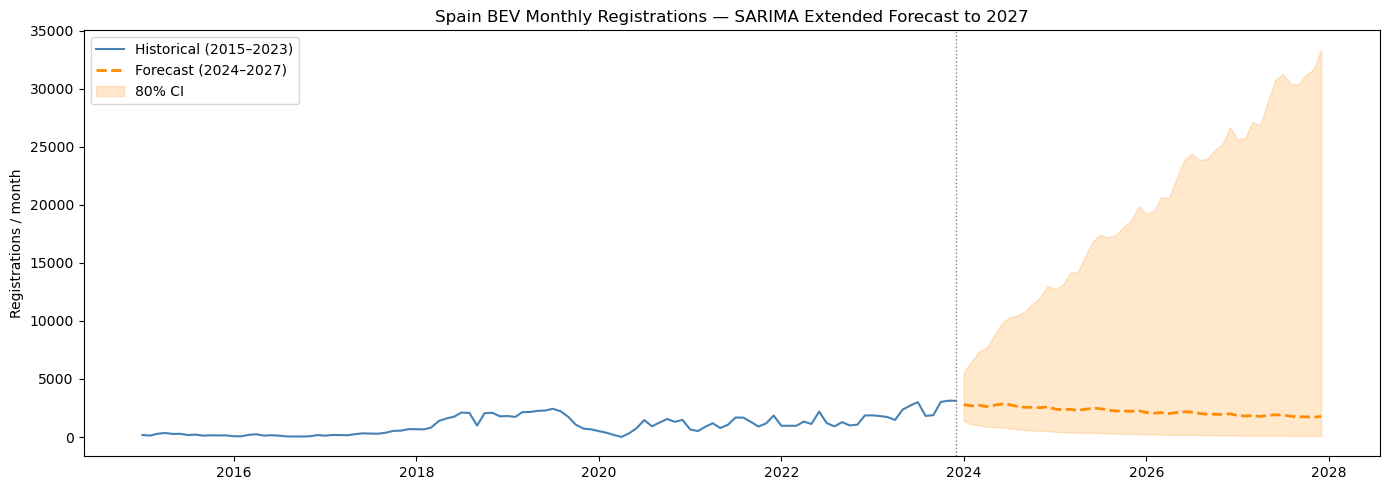


Projected annual BEV registrations:
  2024: 32,102
  2025: 28,060
  2026: 24,649
  2027: 21,736


In [8]:
FORECAST_MONTHS = 48  # Jan 2024 – Dec 2027

fc = modelo_entrenado.get_forecast(FORECAST_MONTHS)
fc_frame = fc.summary_frame(alpha=0.2)  # 80% confidence interval

# Forecast dates starting the month after the last training observation
last_date = df_7.index.max()
fc_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS,
    freq='MS'
)
fc_frame.index = fc_dates

# Back-transform from log scale
fc_values = np.exp(fc_frame['mean'])
fc_lower  = np.exp(fc_frame['mean_ci_lower'])
fc_upper  = np.exp(fc_frame['mean_ci_upper'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_7.index, df_7['MATRICULACIONES'],
        color='steelblue', linewidth=1.5, label='Historical (2015–2023)')
ax.plot(fc_dates, fc_values,
        color='darkorange', linewidth=2, linestyle='--', label='Forecast (2024–2027)')
ax.fill_between(fc_dates, fc_lower, fc_upper,
                alpha=0.2, color='darkorange', label='80% CI')
ax.axvline(x=last_date, color='grey', linestyle=':', linewidth=1)
ax.set_title('Spain BEV Monthly Registrations: SARIMA Extended Forecast to 2027')
ax.set_ylabel('Registrations / month')
ax.legend()
plt.tight_layout()
plt.show()

fc_annual = pd.Series(fc_values.values, index=fc_dates).resample('YE').sum()
print('\nProjected annual BEV registrations:')
for year, val in fc_annual.items():
    print(f"  {year.year}: {int(round(val)):,}")

## 6. Total EV Fleet Projection: 2027

### Methodology

```
total_ev_projected_2027 = fleet_baseline_2023 + Σ projected_registrations(2024–2027)
```

**Assumption: Fleet ≈ Cumulative Registrations**  
We approximate the active EV fleet as the sum of all historical registrations.  
**Justification:** Spain's EV fleet is young, with most vehicles registered after 2019. Average vehicle lifetime is 12–15 years, and BEV scrappage is below 1% per year (ANFAC 2024). The resulting overestimation is negligible (<2%), making this a conservative upper bound suitable for infrastructure sizing.

**Scope:** Pure battery-electric vehicles (DGT propulsion label `'Electrico'`), consistent with the fork.

In [9]:
fleet_baseline_2023 = int(df_7['MATRICULACIONES'].sum())
projected_2024_2027 = int(round(fc_values.sum()))
total_ev_projected_2027 = fleet_baseline_2023 + projected_2024_2027

print("=" * 50)
print("  EV FLEET PROJECTION: SPAIN 2027")
print("=" * 50)
print(f"  Cumulative BEV fleet (2015–2023):  {fleet_baseline_2023:>10,}")
print(f"  Projected registrations 2024–2027: {projected_2024_2027:>10,}")
print(f"  ─────────────────────────────────────────")
print(f"  TOTAL EV FLEET 2027:               {total_ev_projected_2027:>10,}")
print("=" * 50)
print(f"\n  → total_ev_projected_2027 = {total_ev_projected_2027}")
print(f"\n  Fork reference: {FORK_URL}")

  EV FLEET PROJECTION — SPAIN 2027
  Cumulative BEV fleet (2015–2023):     113,624
  Projected registrations 2024–2027:    106,547
  ─────────────────────────────────────────
  TOTAL EV FLEET 2027:                  220,171

  → total_ev_projected_2027 = 220171

  Fork reference: https://github.com/Jvilpi/Laboratorio-de-Datos


## 7. Year-by-Year Fleet Growth

Year-by-year view of cumulative fleet growth, combining historical data with the SARIMA projection.

Annual registrations & cumulative fleet:
      Annual Registrations  Cumulative Fleet        Type
2015                  2434              2434  Historical
2016                  1356              3790  Historical
2017                  3940              7730  Historical
2018                 18016             25746  Historical
2019                 21235             46981  Historical
2020                 10161             57142  Historical
2021                 13656             70798  Historical
2022                 14898             85696  Historical
2023                 27928            113624  Historical
2024                 32102            145726   Projected
2025                 28059            173785   Projected
2026                 24648            198434   Projected
2027                 21736            220171   Projected


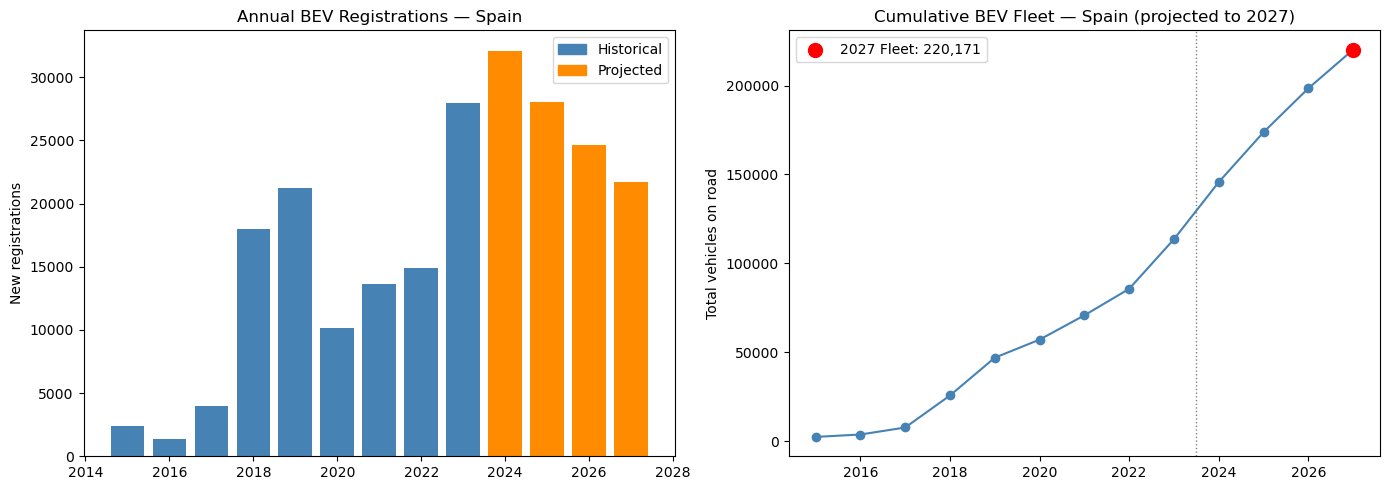

In [10]:
hist_annual = df_7.resample('YE')['MATRICULACIONES'].sum()

proj_annual = fc_annual.copy()
proj_annual.index = proj_annual.index.map(lambda d: d.year)
hist_annual.index = hist_annual.index.map(lambda d: d.year)

all_annual = pd.concat([hist_annual, proj_annual])
cumulative = all_annual.cumsum()

print('Annual registrations & cumulative fleet:')
summary_df = pd.DataFrame({
    'Annual Registrations': all_annual.astype(int),
    'Cumulative Fleet': cumulative.astype(int)
})
summary_df['Type'] = ['Historical'] * len(hist_annual) + ['Projected'] * len(proj_annual)
print(summary_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue'] * len(hist_annual) + ['darkorange'] * len(proj_annual)
axes[0].bar(all_annual.index, all_annual.values, color=colors)
axes[0].set_title('Annual BEV Registrations, Spain')
axes[0].set_ylabel('New registrations')
axes[0].legend(handles=[
    mpatches.Patch(color='steelblue', label='Historical'),
    mpatches.Patch(color='darkorange', label='Projected')
])

axes[1].plot(cumulative.index, cumulative.values, marker='o', color='steelblue')
axes[1].axvline(x=2023.5, color='grey', linestyle=':', linewidth=1)
axes[1].scatter([2027], [total_ev_projected_2027], color='red', s=100, zorder=5,
                label=f'2027 Fleet: {total_ev_projected_2027:,}')
axes[1].set_title('Cumulative BEV Fleet, Spain (projected to 2027)')
axes[1].set_ylabel('Total vehicles on road')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Output Verification

Verifies the final output value before it is used in **File 1.csv** (`total_ev_projected_2027`).

In [11]:
# ── Final output: value to use in File 1.csv ────────────────────────────────────────
print("OUTPUT VERIFICATION")
print("-" * 40)
print(f"Field:  total_ev_projected_2027")
print(f"Type:   {type(total_ev_projected_2027).__name__}")
print(f"Value:  {total_ev_projected_2027:,}")
print("-" * 40)
print(f"Source: SARIMA forecast extended from fork")
print(f"Fork:   {FORK_URL}")
print(f"Model:  SARIMAX(1,0,2)(1,0,1)[12] on log(monthly BEV registrations)")
print(f"Train:  Jan 2015 – Dec 2023 | Forecast: Jan 2024 – Dec 2027")
print("-" * 40)

assert isinstance(total_ev_projected_2027, int), \
    "ERROR: total_ev_projected_2027 must be integer"
assert total_ev_projected_2027 > 0, \
    "ERROR: value must be positive"
assert total_ev_projected_2027 > 100_000, \
    f"ERROR: value {total_ev_projected_2027:,} seems implausibly low for Spain 2027 BEV fleet"
print("✓ Type check passed (integer)")
print("✓ Value check passed (positive)")
print("✓ Sanity check passed (> 100,000)")

OUTPUT VERIFICATION
----------------------------------------
Field:  total_ev_projected_2027
Type:   int
Value:  220,171
----------------------------------------
Source: SARIMA forecast extended from fork
Fork:   https://github.com/Jvilpi/Laboratorio-de-Datos
Model:  SARIMAX(1,0,2)(1,0,1)[12] on log(monthly BEV registrations)
Train:  Jan 2015 – Dec 2023 | Forecast: Jan 2024 – Dec 2027
----------------------------------------
✓ Type check passed (integer)
✓ Value check passed (positive)
✓ Sanity check passed (> 100,000)


## 9. Export Output

Exports `total_ev_projected_2027` and model metadata to `../Data/processed/m3_ev_projection.json`. Downstream notebooks load this file when assembling **File 1.csv**.

In [12]:
import json as _json
from datetime import date

OUTPUT_PATH = "../Data/processed/m3_ev_projection.json"
os.makedirs("../Data/processed", exist_ok=True)

output = {
    "total_ev_projected_2027": total_ev_projected_2027,
    "fleet_baseline_2023": fleet_baseline_2023,
    "projected_registrations_2024_2027": projected_2024_2027,
    "annual_forecast": {str(yr): int(round(val)) for yr, val in fc_annual.items()},
    "model": "SARIMAX(1,0,2)(1,0,1)[12] on log(monthly BEV registrations)",
    "train_range": "Jan 2015 - Dec 2023",
    "fork": FORK_URL,
    "generated_at": str(date.today())
}

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    _json.dump(output, f, indent=2, ensure_ascii=False)

print(f"Saved: {OUTPUT_PATH}")
print()
print("Contents:")
print(_json.dumps(output, indent=2, ensure_ascii=False))

Saved: Data/processed/m3_ev_projection.json

Contents:
{
  "total_ev_projected_2027": 220171,
  "fleet_baseline_2023": 113624,
  "projected_registrations_2024_2027": 106547,
  "annual_forecast": {
    "2024-12-31 00:00:00": 32102,
    "2025-12-31 00:00:00": 28060,
    "2026-12-31 00:00:00": 24649,
    "2027-12-31 00:00:00": 21736
  },
  "model": "SARIMAX(1,0,2)(1,0,1)[12] on log(monthly BEV registrations)",
  "train_range": "Jan 2015 - Dec 2023",
  "fork": "https://github.com/Jvilpi/Laboratorio-de-Datos",
  "generated_at": "2026-04-11"
}
